In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [2]:
# Setup directories
RAW_DIR = r'C:\Users\PC\Downloads\idx-exchange-internship\data\raw'
PROCESSED_DIR = r'C:\Users\PC\Downloads\idx-exchange-internship\data\processed'
os.chdir(PROCESSED_DIR)

In [3]:
# Load the Week 1 combined, Residential-filtered datasets
sold = pd.read_csv('combined_residential_sold.csv', low_memory=False)
listings = pd.read_csv('combined_residential_listings.csv', low_memory=False)

print('Sold shape:', sold.shape)
print('Listings shape:', listings.shape)

Sold shape: (366552, 82)
Listings shape: (574969, 84)


In [4]:
# Property type documentation: reload PropertyType from the raw (pre-filter) monthly files
# to confirm what categories exist before the Week 1 Residential filter was applied
sold_files = sorted(glob.glob(os.path.join(RAW_DIR, 'CRMLSSold*.csv')))
listing_files = sorted(glob.glob(os.path.join(RAW_DIR, 'CRMLSListing*.csv')))

sold_types_raw = pd.concat(
    [pd.read_csv(f, usecols=['PropertyType'], low_memory=False) for f in sold_files],
    ignore_index=True
)
listing_types_raw = pd.concat(
    [pd.read_csv(f, usecols=['PropertyType'], low_memory=False) for f in listing_files],
    ignore_index=True
)

print('--- Sold: PropertyType value counts (pre-filter) ---')
print(sold_types_raw['PropertyType'].value_counts(dropna=False))
print()
print('--- Listings: PropertyType value counts (pre-filter) ---')
print(listing_types_raw['PropertyType'].value_counts(dropna=False))

--- Sold: PropertyType value counts (pre-filter) ---
PropertyType
Residential            412140
ResidentialLease       141426
Land                    19851
ManufacturedInPark      16549
ResidentialIncome       16473
CommercialSale           3841
CommercialLease          3179
BusinessOpportunity       401
Name: count, dtype: int64

--- Listings: PropertyType value counts (pre-filter) ---
PropertyType
Residential            591976
ResidentialLease       192447
Land                    60609
ResidentialIncome       34577
ManufacturedInPark      26634
CommercialSale          12713
CommercialLease          8370
BusinessOpportunity      2982
Name: count, dtype: int64


In [5]:
# Residential share of each raw dataset
sold_res_share = (sold_types_raw['PropertyType'] == 'Residential').mean()
listing_res_share = (listing_types_raw['PropertyType'] == 'Residential').mean()
print(f'Sold: Residential share = {sold_res_share:.2%} ({(sold_types_raw.PropertyType == "Residential").sum():,} of {len(sold_types_raw):,})')
print(f'Listings: Residential share = {listing_res_share:.2%} ({(listing_types_raw.PropertyType == "Residential").sum():,} of {len(listing_types_raw):,})')

Sold: Residential share = 67.14% (412,140 of 613,860)
Listings: Residential share = 63.63% (591,976 of 930,308)


In [6]:
# Confirm the filtering logic already applied in Week 1: both combined datasets
# should now contain only PropertyType == 'Residential'
print('Sold filtered PropertyType values:', sold['PropertyType'].unique())
print('Listings filtered PropertyType values:', listings['PropertyType'].unique())
assert (sold['PropertyType'] == 'Residential').all()
assert (listings['PropertyType'] == 'Residential').all()
print('Filter confirmed: both datasets contain Residential records only.')

Sold filtered PropertyType values: ['Residential']
Listings filtered PropertyType values: ['Residential']
Filter confirmed: both datasets contain Residential records only.


In [7]:
# Data quality check: the raw Listing export contains duplicate columns (e.g. 'PropertyType.1',
# 'ListPrice.1') carried over from the source CSVs. Confirm the duplicates are exact copies, then drop them.
dupe_cols = [c for c in listings.columns if c.endswith('.1')]
print(f'Found {len(dupe_cols)} duplicate-suffixed columns in listings: {dupe_cols}')

for c in dupe_cols:
    base = c[:-2]
    identical = (listings[base].astype(str) == listings[c].astype(str)).all()
    print(f'  {base} vs {c} -> identical: {identical}')

listings = listings.drop(columns=dupe_cols)
print('Listings shape after dropping duplicate columns:', listings.shape)

Found 11 duplicate-suffixed columns in listings: ['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']
  PropertyType vs PropertyType.1 -> identical: True


  ListAgentFirstName vs ListAgentFirstName.1 -> identical: True


  DaysOnMarket vs DaysOnMarket.1 -> identical: True

  LivingArea vs LivingArea.1 -> identical: True


  Longitude vs Longitude.1 -> identical: True


  Latitude vs Latitude.1 -> identical: True


  ListPrice vs ListPrice.1 -> identical: True
  ListAgentLastName vs ListAgentLastName.1 -> identical: True


  CloseDate vs CloseDate.1 -> identical: True


  BuyerOfficeName vs BuyerOfficeName.1 -> identical: True
  UnparsedAddress vs UnparsedAddress.1 -> identical: True


Listings shape after dropping duplicate columns: (574969, 73)


In [8]:
# Dataset understanding: shape and column data types
print('=== SOLD ===')
print('Rows:', sold.shape[0], '| Columns:', sold.shape[1])
print(sold.dtypes.value_counts())
print()
print('=== LISTINGS ===')
print('Rows:', listings.shape[0], '| Columns:', listings.shape[1])
print(listings.dtypes.value_counts())

=== SOLD ===
Rows: 366552 | Columns: 82
object     50
float64    29
int64       3
Name: count, dtype: int64

=== LISTINGS ===
Rows: 574969 | Columns: 73
object     41
float64    29
int64       3
Name: count, dtype: int64


In [9]:
# Separate market-analysis fields (used for metrics/dashboards) from metadata/administrative fields
market_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres',
    'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt',
    'PropertyType', 'PropertySubType', 'CountyOrParish', 'MLSAreaMajor', 'City', 'PostalCode',
    'CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate',
    'Latitude', 'Longitude', 'ListOfficeName', 'BuyerOfficeName'
]
metadata_fields = [c for c in sold.columns if c not in market_fields]
print(f'Market analysis fields ({len(market_fields)}):')
print(market_fields)
print()
print(f'Metadata / administrative fields ({len(metadata_fields)}):')
print(metadata_fields)

Market analysis fields (23):
['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt', 'PropertyType', 'PropertySubType', 'CountyOrParish', 'MLSAreaMajor', 'City', 'PostalCode', 'CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate', 'Latitude', 'Longitude', 'ListOfficeName', 'BuyerOfficeName']

Metadata / administrative fields (59):
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'ListingKey', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'TaxAnnualAmount', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderNa

In [10]:
# Missing value analysis: counts and percentages per column
def missing_report(df, name):
    report = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_pct': (df.isnull().mean() * 100).round(2)
    }).sort_values('missing_pct', ascending=False)
    high_missing = report[report['missing_pct'] > 90]
    print(f'--- {name}: top 15 columns by missing % ---')
    print(report.head(15))
    print(f'\n{name}: {len(high_missing)} column(s) above 90% missing')
    if len(high_missing):
        print(high_missing)
    return report

sold_missing = missing_report(sold, 'SOLD')
listings_missing = missing_report(listings, 'LISTINGS')

--- SOLD: top 15 columns by missing % ---
                              missing_count  missing_pct
AboveGradeFinishedArea               366552       100.00
FireplacesTotal                      366552       100.00
TaxYear                              366552       100.00
ElementarySchoolDistrict             366552       100.00
CoveredSpaces                        366552       100.00
BusinessType                         366552       100.00
MiddleOrJuniorSchoolDistrict         366552       100.00
TaxAnnualAmount                      366552       100.00
WaterfrontYN                         366321        99.94
BelowGradeFinishedArea               364333        99.39
BasementYN                           359351        98.04
LotSizeDimensions                    348586        95.10
BuilderName                          348395        95.05
BuildingAreaTotal                    340506        92.89
CoBuyerAgentFirstName                332938        90.83

SOLD: 15 column(s) above 90% missing
        

--- LISTINGS: top 15 columns by missing % ---
                              missing_count  missing_pct
FireplacesTotal                      574969       100.00
TaxYear                              574969       100.00
ElementarySchoolDistrict             574969       100.00
BusinessType                         574969       100.00
CoveredSpaces                        574969       100.00
MiddleOrJuniorSchoolDistrict         574969       100.00
TaxAnnualAmount                      574969       100.00
AboveGradeFinishedArea               574969       100.00
BelowGradeFinishedArea               571664        99.43
CoBuyerAgentFirstName                561871        97.72
BuilderName                          548406        95.38
LotSizeDimensions                    544824        94.76
BuildingAreaTotal                    523555        91.06
BuyerAgencyCompensation              512977        89.22
BuyerAgencyCompensationType          512963        89.22

LISTINGS: 13 column(s) above 90% missing


In [11]:
# Decision: retain core fields (ClosePrice, LivingArea, DaysOnMarket, etc.) even if partially missing.
# Only columns above the 90% missing threshold are candidates for dropping; save the full null-count
# tables so the decision is documented and auditable.
sold_missing.to_csv('sold_missing_value_report.csv')
listings_missing.to_csv('listings_missing_value_report.csv')
print('Saved missing value reports.')

Saved missing value reports.


In [12]:
# Numeric distribution review: percentile summary for the key numeric fields
numeric_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres',
    'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt'
]
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
dist_summary = sold[numeric_fields].describe(percentiles=percentiles).T
dist_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,366551.0,1.193901e+06,6.535079e+06,0.0,200000.00,339000.00,575000.00,820000.0000,1.299000e+06,2850000.00,5.554500e+06,9.895000e+08
ListPrice,366552.0,1.138377e+06,1.365638e+06,525.0,212945.12,345000.00,575000.00,810000.0000,1.290000e+06,2850000.00,5.700000e+06,1.375000e+08
OriginalListPrice,365858.0,1.230729e+06,7.113432e+06,0.0,210000.00,349900.00,585000.00,825000.0000,1.299000e+06,2899000.00,5.995000e+06,1.390000e+09
LivingArea,366346.0,1.910396e+03,2.813644e+04,0.0,605.00,840.00,1248.00,1645.0000,2.221000e+03,3560.00,5.267000e+03,1.702132e+07
LotSizeAcres,338461.0,7.256962e+01,1.697959e+04,0.0,0.00,0.03,0.12,0.1667,2.755000e-01,2.91,1.090384e+01,7.810698e+06
BedroomsTotal,366541.0,3.203483e+00,1.068133e+00,0.0,1.00,2.00,3.00,3.0000,4.000000e+00,5.00,6.000000e+00,4.500000e+01
BathroomsTotalInteger,366495.0,2.537628e+00,1.139745e+00,0.0,1.00,1.00,2.00,2.0000,3.000000e+00,4.00,6.000000e+00,1.750000e+02
DaysOnMarket,366552.0,3.845963e+01,5.120843e+01,-288.0,0.00,1.00,8.00,19.0000,5.000000e+01,135.00,2.360000e+02,2.177000e+03
YearBuilt,366234.0,1.978641e+03,2.634520e+01,1776.0,1912.00,1930.00,1960.00,1979.0000,1.999000e+03,2023.00,2.025000e+03,2.026000e+03


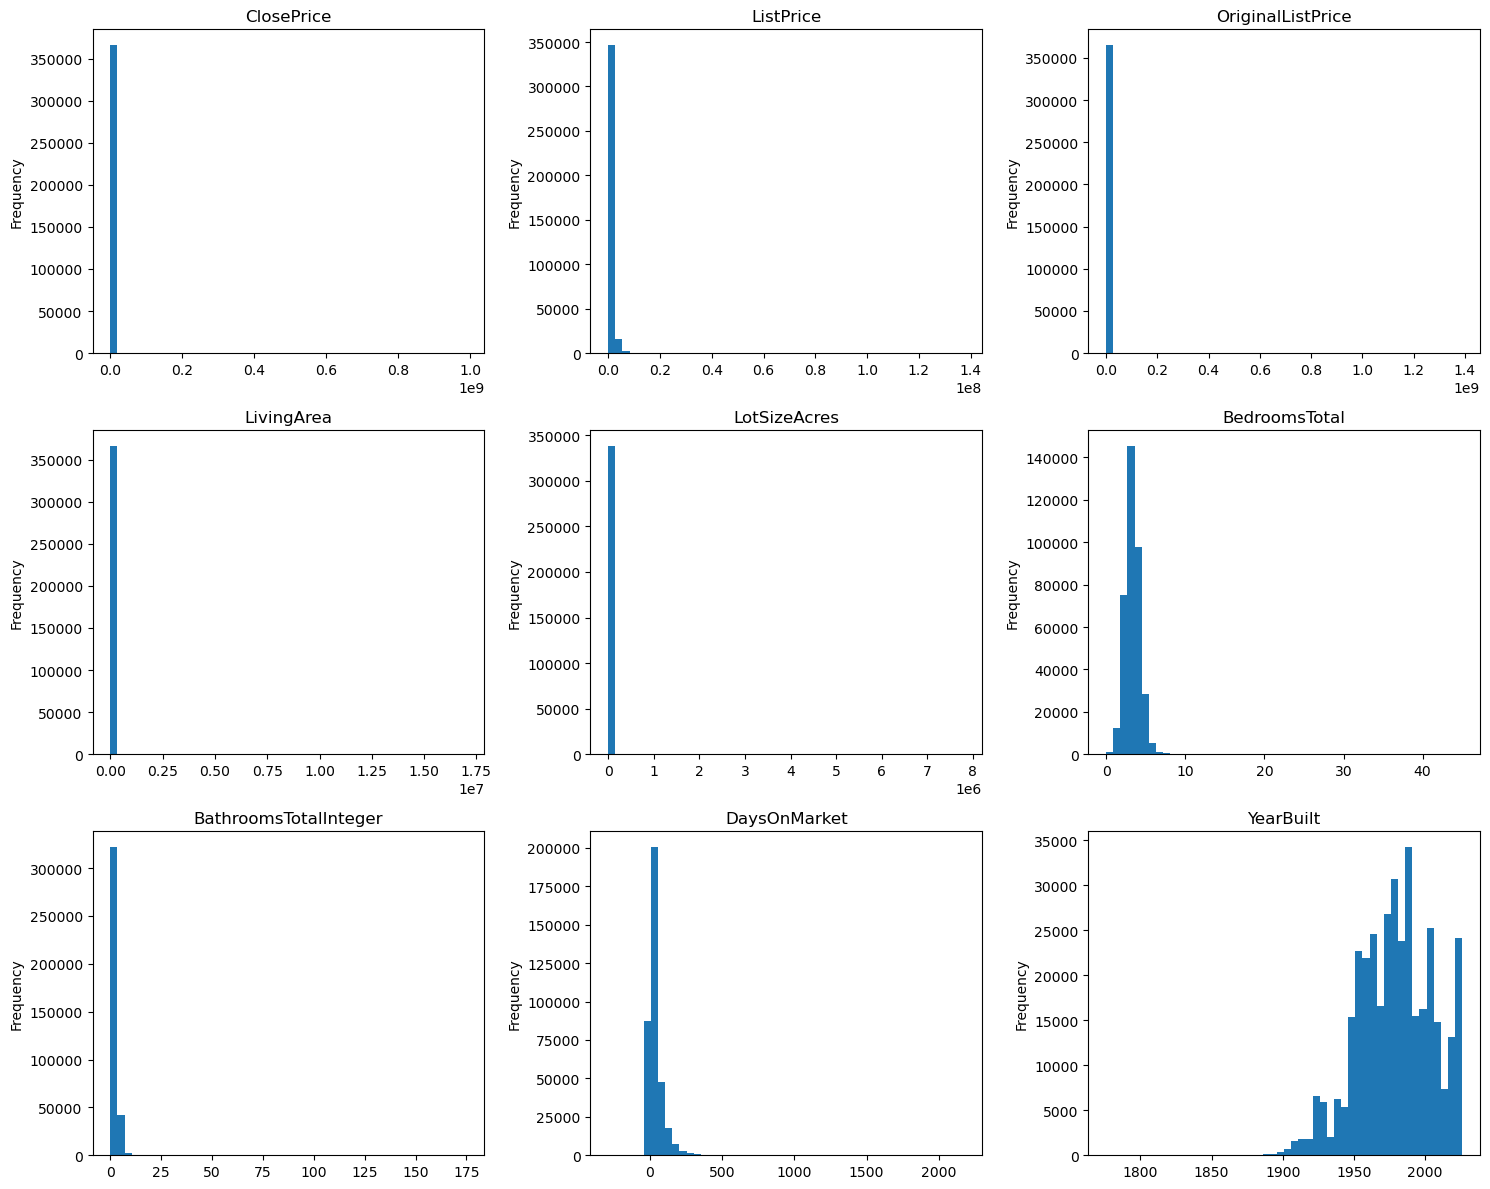

In [13]:
# Histograms for the key numeric fields (Sold dataset)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_fields):
    sold[col].dropna().plot(kind='hist', bins=50, ax=ax, title=col)
plt.tight_layout()
plt.savefig('sold_numeric_histograms.png')
plt.show()

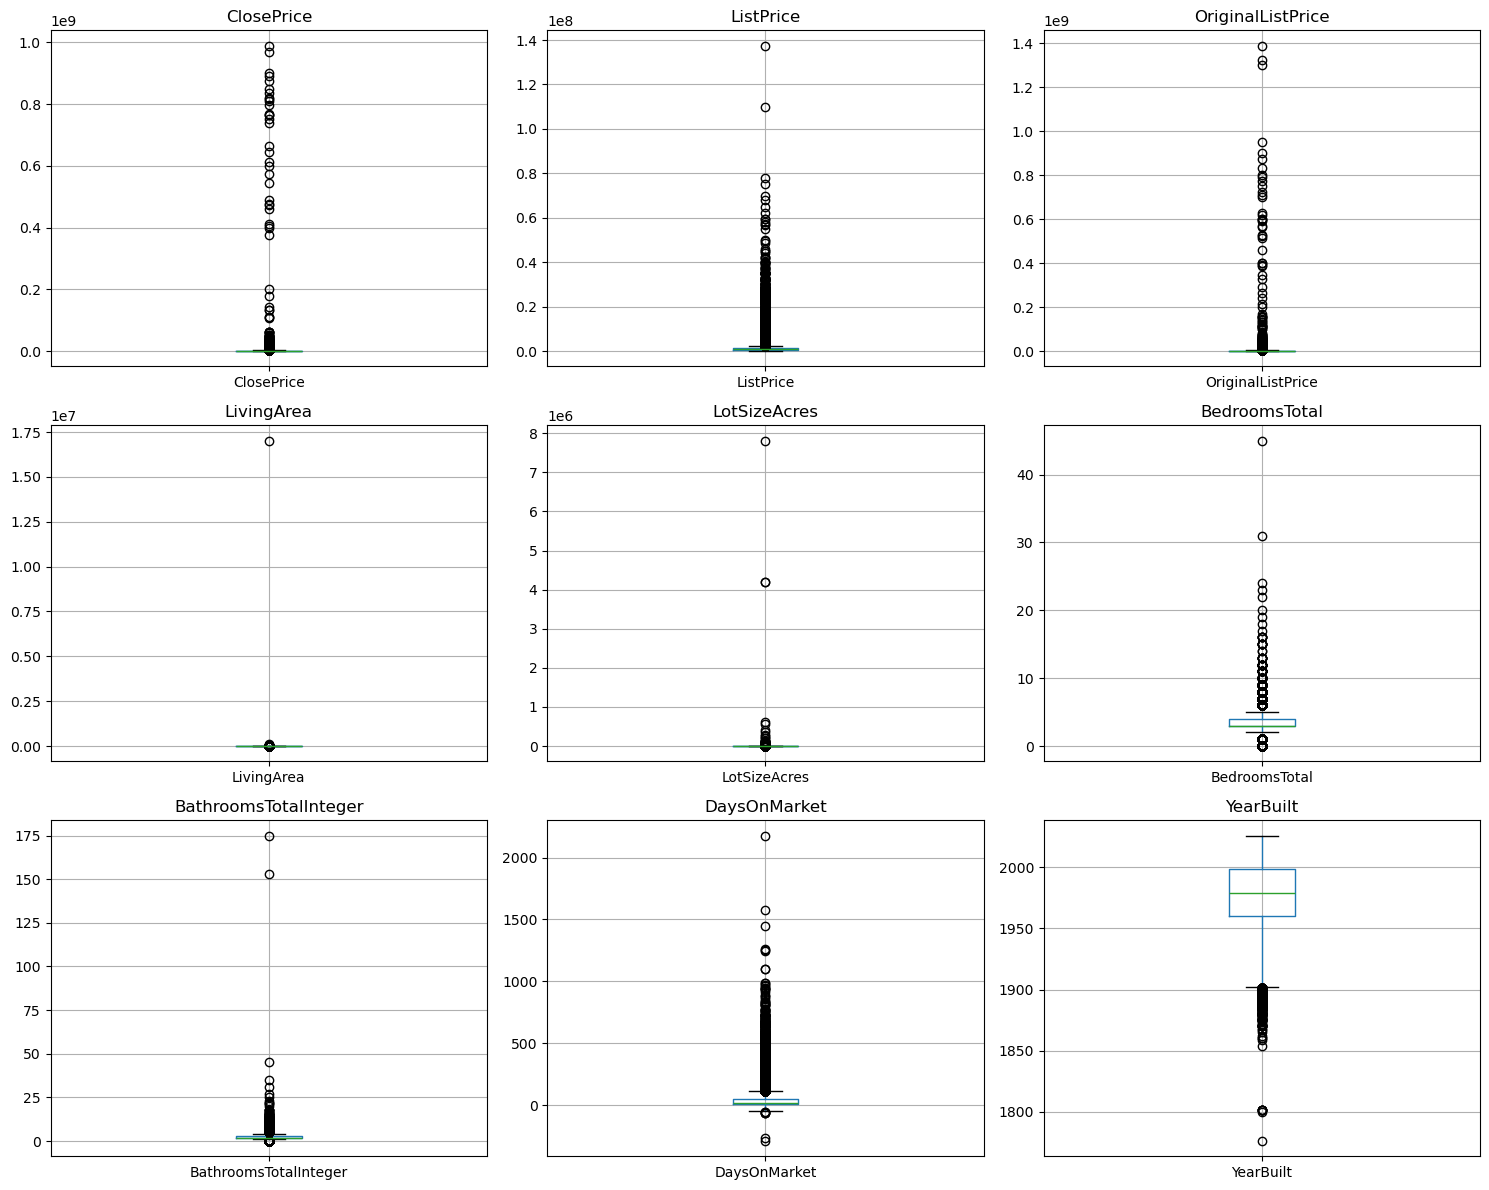

In [14]:
# Boxplots for the key numeric fields (Sold dataset)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_fields):
    sold.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('sold_numeric_boxplots.png')
plt.show()

In [15]:
# Extreme outlier identification (flagging only -- removal is handled in Week 7 with IQR)
print('Values outside the 1st-99th percentile range (candidates for later outlier handling):')
for col in numeric_fields:
    p01, p99 = sold[col].quantile([0.01, 0.99])
    n_extreme = (~sold[col].between(p01, p99)).sum()
    print(f'  {col}: {n_extreme:,} rows outside [{p01:,.1f}, {p99:,.1f}]')

Values outside the 1st-99th percentile range (candidates for later outlier handling):
  ClosePrice: 7,118 rows outside [200,000.0, 5,554,500.0]
  ListPrice: 7,326 rows outside [212,945.1, 5,700,000.0]
  OriginalListPrice: 7,778 rows outside [210,000.0, 5,995,000.0]
  LivingArea: 7,524 rows outside [605.0, 5,267.0]
  LotSizeAcres: 31,476 rows outside [0.0, 10.9]
  BedroomsTotal: 2,675 rows outside [1.0, 6.0]
  BathroomsTotalInteger: 2,868 rows outside [1.0, 6.0]
  DaysOnMarket: 3,693 rows outside [0.0, 236.0]
  YearBuilt: 4,623 rows outside [1,912.0, 2,025.0]


In [16]:
# Required deliverable: distribution summary (min, max, mean, median, percentiles) for
# ClosePrice, LivingArea, DaysOnMarket
required_fields = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
required_summary = sold[required_fields].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
required_summary.to_csv('sold_numeric_distribution_summary.csv')
required_summary

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
ClosePrice,366551.0,1.193901e+06,6.535079e+06,0.0,339000.0,575000.0,820000.0,1299000.0,2850000.0,5554500.0,989500000.0
LivingArea,366346.0,1.910396e+03,2.813644e+04,0.0,840.0,1248.0,1645.0,2221.0,3560.0,5267.0,17021321.0
DaysOnMarket,366552.0,3.845963e+01,5.120843e+01,-288.0,1.0,8.0,19.0,50.0,135.0,236.0,2177.0


In [17]:
# Note on scope: the Suggested Intern Questions above (median/avg close price, % over/under list,
# date consistency) are computed on the SOLD dataset only, since it is the authoritative closed-transaction
# table. The LISTINGS dataset does carry ClosePrice/CloseDate columns, but they are populated only for
# listings that have since closed (~77% and ~73% null respectively) -- those closed records are already
# captured in SOLD, so re-deriving these metrics from LISTINGS would be redundant and partially null.
print('Listings ClosePrice null %:', round(listings["ClosePrice"].isnull().mean() * 100, 1))
print('Listings CloseDate null %:', round(listings["CloseDate"].isnull().mean() * 100, 1))
print('Listings MlsStatus breakdown:')
print(listings["MlsStatus"].value_counts(dropna=False))


Listings ClosePrice null %: 77.4


Listings CloseDate null %: 73.4
Listings MlsStatus breakdown:
MlsStatus
Active                 300837
Closed                 129733
Pending                 95789
ActiveUnderContract     46676
ComingSoon               1934
Name: count, dtype: int64


In [18]:
# --- Suggested Intern Questions ---

# 1. Residential vs. other property type share (computed above from raw pre-filter data)
print(f'1. Residential share -- Sold: {sold_res_share:.2%}, Listings: {listing_res_share:.2%}')

1. Residential share -- Sold: 67.14%, Listings: 63.63%


In [19]:
# 2. Median and average close prices
print('2. Median close price: ${:,.0f}'.format(sold['ClosePrice'].median()))
print('   Average close price: ${:,.0f}'.format(sold['ClosePrice'].mean()))

2. Median close price: $820,000
   Average close price: $1,193,901


In [20]:
# 3. Days on Market distribution
print('3. Days on Market distribution:')
print(sold['DaysOnMarket'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

3. Days on Market distribution:
count    366552.000000
mean         38.459635
std          51.208431
min        -288.000000
25%           8.000000
50%          19.000000
75%          50.000000
90%          97.000000
99%         236.000000
max        2177.000000
Name: DaysOnMarket, dtype: float64


In [21]:
# 4. Percentage of homes sold above vs. below list price
valid_price = sold.dropna(subset=['ClosePrice', 'ListPrice'])
above = (valid_price['ClosePrice'] > valid_price['ListPrice']).mean()
below = (valid_price['ClosePrice'] < valid_price['ListPrice']).mean()
at_list = (valid_price['ClosePrice'] == valid_price['ListPrice']).mean()
print(f'4. Sold above list: {above:.2%} | Sold below list: {below:.2%} | Sold at list: {at_list:.2%}')

4. Sold above list: 38.91% | Sold below list: 43.61% | Sold at list: 17.48%


In [22]:
# 5. Date consistency: does CloseDate ever precede ListingContractDate?
close_dt = pd.to_datetime(sold['CloseDate'], errors='coerce')
listing_dt = pd.to_datetime(sold['ListingContractDate'], errors='coerce')
inconsistent = (close_dt < listing_dt).sum()
print(f'5. Records where CloseDate precedes ListingContractDate: {inconsistent:,} '
      f'({inconsistent / len(sold):.2%} of sold records)')

5. Records where CloseDate precedes ListingContractDate: 58 (0.02% of sold records)


In [23]:
# 6. Counties with the highest median close prices (min 30 sales to avoid noise from tiny counties)
county_counts = sold['CountyOrParish'].value_counts()
eligible_counties = county_counts[county_counts >= 30].index
county_median = (
    sold[sold['CountyOrParish'].isin(eligible_counties)]
    .groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)
print('6. Top 10 counties by median close price (>=30 sales):')
print(county_median.head(10))

6. Top 10 counties by median close price (>=30 sales):
CountyOrParish
San Mateo        1680000.0
Santa Clara      1585000.0
Santa Cruz       1199944.0
Marin            1199500.0
San Francisco    1180000.0
Orange           1175000.0
Alameda          1127000.0
Monterey          905000.0
Los Angeles       900000.0
San Diego         895000.0
Name: ClosePrice, dtype: float64


In [24]:
# Segment summary tables (feeds the Week 6 feature engineering step)
segment_by_county = sold.groupby('CountyOrParish').agg(
    median_close_price=('ClosePrice', 'median'),
    avg_days_on_market=('DaysOnMarket', 'mean'),
    n_sales=('ClosePrice', 'count')
).sort_values('n_sales', ascending=False)
segment_by_county.to_csv('sold_segment_summary_by_county.csv')
segment_by_county.head(10)

,median_close_price,avg_days_on_market,n_sales
CountyOrParish,,,
Los Angeles,900000.0,37.455861,91653
Riverside,600000.0,49.651493,51118
San Diego,895000.0,30.369059,45570
Orange,1175000.0,32.681484,41257
San Bernardino,532000.0,47.584580,34293
Alameda,1127000.0,26.509707,17255
Contra Costa,818600.0,29.584730,16647
Santa Clara,1585000.0,22.900370,15126
Ventura,870000.0,44.456631,11552


In [25]:
# Save the structured/validated datasets as new CSVs (Weeks 2-3 checkpoint)
sold.to_csv('sold_structured_validated.csv', index=False)
listings.to_csv('listings_structured_validated.csv', index=False)
print('Saved sold_structured_validated.csv:', sold.shape)
print('Saved listings_structured_validated.csv:', listings.shape)

Saved sold_structured_validated.csv: (366552, 82)
Saved listings_structured_validated.csv: (574969, 73)


In [26]:
# ============================================================
# Mortgage Rate Enrichment
# Fetch the FRED MORTGAGE30US series, resample to monthly, and merge
# onto both combined datasets using a year_month key.
# ============================================================

# Step 1 - Fetch the mortgage rate data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']
print('Fetched', len(mortgage), 'weekly mortgage rate observations.')
mortgage.tail()

Fetched 2884 weekly mortgage rate observations.


,date,rate_30yr_fixed
2879,2026-06-04,6.48
2880,2026-06-11,6.52
2881,2026-06-18,6.47
2882,2026-06-25,6.49
2883,2026-07-02,6.43


In [27]:
# Step 2 - Resample weekly rates to monthly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)
mortgage_monthly.tail()

,year_month,rate_30yr_fixed
659,2026-03,6.1775
660,2026-04,6.3320
661,2026-05,6.4425
662,2026-06,6.4900
663,2026-07,6.4300


In [28]:
# Step 3 - Create a matching year_month key on the MLS datasets
# Sold dataset -- key off CloseDate
sold['year_month'] = pd.to_datetime(sold['CloseDate'], errors='coerce').dt.to_period('M')

# Listings dataset -- key off ListingContractDate
listings['year_month'] = pd.to_datetime(listings['ListingContractDate'], errors='coerce').dt.to_period('M')

# Step 4 - Merge
sold_with_rates = sold.merge(mortgage_monthly, on='year_month', how='left')
listings_with_rates = listings.merge(mortgage_monthly, on='year_month', how='left')

# Step 5 - Validate the merge: rate should not be null for any row
sold_nulls = sold_with_rates['rate_30yr_fixed'].isnull().sum()
listings_nulls = listings_with_rates['rate_30yr_fixed'].isnull().sum()
print('Sold rows with null rate after merge:', sold_nulls)
print('Listings rows with null rate after merge:', listings_nulls)
assert sold_nulls == 0, 'Unmatched rows found in sold_with_rates'
assert listings_nulls == 0, 'Unmatched rows found in listings_with_rates'
print('Validation passed: no null mortgage rate values after merge.')

Sold rows with null rate after merge: 0
Listings rows with null rate after merge: 0
Validation passed: no null mortgage rate values after merge.


In [29]:
# Preview
print(sold_with_rates[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

    CloseDate year_month  ClosePrice  rate_30yr_fixed
0  2024-01-26    2024-01    240000.0           6.6425
1  2024-01-05    2024-01    815000.0           6.6425
2  2024-01-05    2024-01    810000.0           6.6425
3  2024-01-30    2024-01    858000.0           6.6425
4  2024-01-29    2024-01   1890500.0           6.6425


In [30]:
# Save enriched datasets
sold_with_rates.to_csv('sold_with_mortgage_rates.csv', index=False)
listings_with_rates.to_csv('listings_with_mortgage_rates.csv', index=False)
print('Saved sold_with_mortgage_rates.csv:', sold_with_rates.shape)
print('Saved listings_with_mortgage_rates.csv:', listings_with_rates.shape)

Saved sold_with_mortgage_rates.csv: (366552, 84)
Saved listings_with_mortgage_rates.csv: (574969, 75)
